In [2]:
!pip install librosa soundfile pandas numpy matplotlib scikit-learn tensorflow tensorflow_hub

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached soundfile-0.13.1-py2.py3-none-manylinux_2_28_x86_64.whl.metadata (16 kB)
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached numba-0.65.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.1.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.8 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached msgpack-1.1.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.1 kB)
  Using cached tf_keras-2.21.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached llvmlite-0.47.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.0 kB)
  Using cached tensorflow-2.21.0-cp311-cp311-manylinux_2_27_x86_64.

In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, models, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

I0000 00:00:1778184520.781095      71 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778184522.721138      71 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
# Download and extract UrbanSound8K.
!wget -nc -O UrbanSound8K.tar.gz "https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz?download=1"
!tar -xzf UrbanSound8K.tar.gz

File ‘UrbanSound8K.tar.gz’ already there; not retrieving.


In [5]:
DATA_DIR = "UrbanSound8K"
META_PATH = os.path.join(DATA_DIR, "metadata", "UrbanSound8K.csv")

df = pd.read_csv(META_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nSound class distribution:")
display(df["class"].value_counts())

print("\nSalience distribution:")
display(df["salience"].value_counts())

print("\nFold distribution:")
display(df["fold"].value_counts().sort_index())

Dataset shape: (8732, 8)


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing



Sound class distribution:


class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
jackhammer          1000
engine_idling       1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64


Salience distribution:


salience
1    5702
2    3030
Name: count, dtype: int64


Fold distribution:


fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64

In [6]:
# I use only folds 1, 2 and 3 to keep training time manageable.
# Folds 1 and 2 are used for training.
# Fold 3 is held out for final testing.

df_small = df[df["fold"].isin([1, 2, 3])].copy()

train_df = df_small[df_small["fold"].isin([1, 2])].copy()
test_df = df_small[df_small["fold"] == 3].copy()

def get_audio_path(row):
    return os.path.join(
        DATA_DIR,
        "audio",
        f"fold{row['fold']}",
        row["slice_file_name"]
    )

train_df["path"] = train_df.apply(get_audio_path, axis=1)
test_df["path"] = test_df.apply(get_audio_path, axis=1)

# Salience in UrbanSound8K:
# 1 = foreground, 2 = background.
# I convert this to binary labels for the CNN:
# 0 = foreground, 1 = background.
train_df["salience_label"] = train_df["salience"].map({1: 0, 2: 1})
test_df["salience_label"] = test_df["salience"].map({1: 0, 2: 1})

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (1761, 10)
Test: (925, 10)


In [7]:
# These checks confirm that the test fold is not used during training.

print("Train folds:", sorted(train_df["fold"].unique()))
print("Test folds:", sorted(test_df["fold"].unique()))

train_files = set(train_df["slice_file_name"])
test_files = set(test_df["slice_file_name"])

file_overlap = train_files.intersection(test_files)
print("Overlapping files:", len(file_overlap))

train_paths = set(train_df["path"])
test_paths = set(test_df["path"])

path_overlap = train_paths.intersection(test_paths)
print("Overlapping paths:", len(path_overlap))

print("\nTrain salience distribution:")
display(train_df["salience_label"].value_counts())

print("\nTest salience distribution:")
display(test_df["salience_label"].value_counts())

Train folds: [1, 2]
Test folds: [3]
Overlapping files: 0
Overlapping paths: 0

Train salience distribution:


salience_label
0    1180
1     581
Name: count, dtype: int64


Test salience distribution:


salience_label
0    590
1    335
Name: count, dtype: int64

In [8]:
# Task 1: sound source classification.
# YAMNet is used as a frozen pretrained feature extractor.
# The model itself is not trained; only a logistic regression classifier is trained on top.

yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

def yamnet_embedding(path):
    y, sr = librosa.load(path, sr=16000, mono=True)
    waveform = tf.convert_to_tensor(y, dtype=tf.float32)
    
    scores, embeddings, spectrogram = yamnet(waveform)
    
    # YAMNet gives embeddings over time.
    # I average them to get one fixed-size vector per audio clip.
    return tf.reduce_mean(embeddings, axis=0).numpy()

print("Extracting YAMNet embeddings for training set...")
X_train_yamnet = np.array([yamnet_embedding(p) for p in train_df["path"]])

print("Extracting YAMNet embeddings for test set...")
X_test_yamnet = np.array([yamnet_embedding(p) for p in test_df["path"]])

print("Train embeddings:", X_train_yamnet.shape)
print("Test embeddings:", X_test_yamnet.shape)

Extracting YAMNet embeddings for training set...


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting YAMNet embeddings for test set...
Train embeddings: (1761, 1024)
Test embeddings: (925, 1024)


In [9]:
label_encoder = LabelEncoder()

y_train_class = label_encoder.fit_transform(train_df["class"])
y_test_class = label_encoder.transform(test_df["class"])

yamnet_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

yamnet_clf.fit(X_train_yamnet, y_train_class)

yamnet_preds = yamnet_clf.predict(X_test_yamnet)
yamnet_acc = accuracy_score(y_test_class, yamnet_preds)

print("YAMNet sound source classification accuracy:", yamnet_acc)

print(classification_report(
    y_test_class,
    yamnet_preds,
    target_names=label_encoder.classes_
))

print("Confusion matrix:")
print(confusion_matrix(y_test_class, yamnet_preds))

yamnet_test_results = test_df.copy()
yamnet_test_results["true_class"] = test_df["class"].values
yamnet_test_results["yamnet_pred_class"] = label_encoder.inverse_transform(yamnet_preds)
yamnet_test_results["yamnet_correct"] = (
    yamnet_test_results["true_class"] == yamnet_test_results["yamnet_pred_class"]
)

yamnet_results = pd.DataFrame({
    "System": ["Pretrained YAMNet + Logistic Regression"],
    "Task": ["Sound source classification"],
    "Test accuracy": [yamnet_acc]
})

display(yamnet_results)

YAMNet sound source classification accuracy: 0.6918918918918919
                  precision    recall  f1-score   support

 air_conditioner       0.62      0.32      0.42       100
        car_horn       0.79      0.98      0.88        43
children_playing       0.81      0.85      0.83       100
        dog_bark       0.86      0.82      0.84       100
        drilling       0.51      0.93      0.66       100
   engine_idling       0.51      0.38      0.44       107
        gun_shot       0.97      1.00      0.99        36
      jackhammer       0.50      0.49      0.49       120
           siren       0.96      0.83      0.89       119
    street_music       0.71      0.71      0.71       100

        accuracy                           0.69       925
       macro avg       0.72      0.73      0.71       925
    weighted avg       0.70      0.69      0.68       925

Confusion matrix:
[[32  0  4  8 19 25  0  9  0  3]
 [ 0 42  0  0  0  0  0  0  0  1]
 [ 1  0 85  1  3  2  0  0  0  8]
 [ 4

,System,Task,Test accuracy
0,Pretrained YAMNet + Logistic Regression,Sound source classification,0.691892


In [10]:
print("YAMNet accuracy by class:")
display(
    yamnet_test_results.groupby("true_class")["yamnet_correct"]
    .mean()
    .sort_values(ascending=False)
)

print("Most common YAMNet mistakes:")
display(
    yamnet_test_results[yamnet_test_results["yamnet_correct"] == False]
    .groupby(["true_class", "yamnet_pred_class"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

YAMNet accuracy by class:


true_class
gun_shot            1.000000
car_horn            0.976744
drilling            0.930000
children_playing    0.850000
siren               0.831933
dog_bark            0.820000
street_music        0.710000
jackhammer          0.491667
engine_idling       0.383178
air_conditioner     0.320000
Name: yamnet_correct, dtype: float64

Most common YAMNet mistakes:


,true_class,yamnet_pred_class,count
29,jackhammer,drilling,54
26,engine_idling,jackhammer,41
3,air_conditioner,engine_idling,25
2,air_conditioner,drilling,19
24,engine_idling,drilling,12
38,street_music,car_horn,10
4,air_conditioner,jackhammer,9
36,siren,street_music,9
39,street_music,children_playing,9
1,air_conditioner,dog_bark,8


In [11]:
# Task 2: foreground/background salience classification.
# I use mel spectrograms because CNNs work well with time-frequency representations.

SR = 16000
N_MELS = 64
MAX_LEN = 128

def make_mel(path):
    y, sr = librosa.load(path, sr=SR, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS,
        n_fft=1024,
        hop_length=512
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Pad or crop each spectrogram to the same shape.
    if mel_db.shape[1] < MAX_LEN:
        mel_db = np.pad(
            mel_db,
            ((0, 0), (0, MAX_LEN - mel_db.shape[1])),
            mode="constant"
        )
    else:
        mel_db = mel_db[:, :MAX_LEN]

    return mel_db

print("Creating mel spectrograms...")
X_train_full = np.array([make_mel(p) for p in train_df["path"]])
X_test_sal = np.array([make_mel(p) for p in test_df["path"]])

y_train_full_sal = train_df["salience_label"].values
y_test_sal = test_df["salience_label"].values

print("Training spectrograms:", X_train_full.shape)
print("Test spectrograms:", X_test_sal.shape)

Creating mel spectrograms...


/opt/conda/lib/python3.11/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=960
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=800
  warnings.warn(


Training spectrograms: (1761, 64, 128)
Test spectrograms: (925, 64, 128)


In [12]:
# The validation set is made only from the training folds.
# Fold 3 remains untouched until final testing.

X_train_sal, X_val_sal, y_train_sal, y_val_sal = train_test_split(
    X_train_full,
    y_train_full_sal,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full_sal
)

# Normalization statistics are calculated from training data only.
# This avoids leaking information from validation or test data.
train_mean = X_train_sal.mean()
train_std = X_train_sal.std()

X_train_sal = (X_train_sal - train_mean) / train_std
X_val_sal = (X_val_sal - train_mean) / train_std
X_test_sal = (X_test_sal - train_mean) / train_std

X_train_sal = X_train_sal[..., np.newaxis]
X_val_sal = X_val_sal[..., np.newaxis]
X_test_sal = X_test_sal[..., np.newaxis]

print("Train:", X_train_sal.shape)
print("Validation:", X_val_sal.shape)
print("Test:", X_test_sal.shape)

Train: (1408, 64, 128, 1)
Validation: (353, 64, 128, 1)
Test: (925, 64, 128, 1)


In [19]:
# CNN without early stopping so it has enough time to learn.
# The validation set is still used only for threshold selection.

tf.random.set_seed(42)
np.random.seed(42)

cnn_salience = models.Sequential([
    layers.Input(shape=(N_MELS, MAX_LEN, 1)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

cnn_salience.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = cnn_salience.fit(
    X_train_sal,
    y_train_sal,
    validation_data=(X_val_sal, y_val_sal),
    epochs=25,
    batch_size=32,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 308ms/step - accuracy: 0.5447 - loss: 0.6972 - val_accuracy: 0.6374 - val_loss: 0.6582
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 303ms/step - accuracy: 0.6392 - loss: 0.6197 - val_accuracy: 0.6714 - val_loss: 0.6328
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 297ms/step - accuracy: 0.6804 - loss: 0.5770 - val_accuracy: 0.6714 - val_loss: 0.6170
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 306ms/step - accuracy: 0.7180 - loss: 0.5387 - val_accuracy: 0.6771 - val_loss: 0.6190
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 299ms/step - accuracy: 0.7436 - loss: 0.5156 - val_accuracy: 0.6714 - val_loss: 0.6754
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 298ms/step - accuracy: 0.7848 - loss: 0.4605 - val_accuracy: 0.6714 - val_loss: 0.7616
Epoch 7/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 297ms/step - accuracy: 0.8047 - loss: 0.4151 - val_accuracy: 0.6742 - val_loss: 0.8758
Epoch 8/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 294ms/step - accuracy: 0.8395 - loss: 0.3628 - val_accu

In [20]:
# The CNN outputs a probability of "background".
# Instead of assuming 0.5 is the best threshold, I choose the threshold
# that gives the best macro-F1 on the validation set.

val_probs = cnn_salience.predict(X_val_sal).flatten()

thresholds = np.arange(0.1, 0.91, 0.01)
threshold_rows = []

for threshold in thresholds:
    val_preds = (val_probs >= threshold).astype(int)
    
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val_sal, val_preds),
        "macro_f1": f1_score(y_val_sal, val_preds, average="macro"),
        "background_f1": f1_score(y_val_sal, val_preds, pos_label=1)
    })

threshold_df = pd.DataFrame(threshold_rows)

display(threshold_df.sort_values("macro_f1", ascending=False).head(10))

best_threshold = threshold_df.sort_values("macro_f1", ascending=False).iloc[0]["threshold"]

print("Best validation threshold:", best_threshold)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step


,threshold,accuracy,macro_f1,background_f1
0,0.10,0.864023,0.841526,0.781818
6,0.16,0.864023,0.834544,0.764706
1,0.11,0.858357,0.834092,0.770642
8,0.18,0.864023,0.833569,0.762376
7,0.17,0.864023,0.833569,0.762376
3,0.13,0.861190,0.833479,0.765550
2,0.12,0.858357,0.831468,0.764151
4,0.14,0.858357,0.829607,0.759615
9,0.19,0.861190,0.829595,0.756219
5,0.15,0.858357,0.828641,0.757282


Best validation threshold: 0.1


In [21]:
# Fold 3 is used here for the final CNN evaluation.

test_probs_sal = cnn_salience.predict(X_test_sal).flatten()
test_preds_sal = (test_probs_sal >= best_threshold).astype(int)

salience_acc = accuracy_score(y_test_sal, test_preds_sal)

print("CNN salience test accuracy:", salience_acc)
print("Threshold used:", best_threshold)

print(classification_report(
    y_test_sal,
    test_preds_sal,
    target_names=["foreground", "background"]
))

print("Confusion matrix:")
print(confusion_matrix(y_test_sal, test_preds_sal))

test_df_salience_results = test_df.copy()
test_df_salience_results["true_salience_name"] = test_df_salience_results["salience_label"].map({
    0: "foreground",
    1: "background"
})
test_df_salience_results["cnn_salience_prob_background"] = test_probs_sal
test_df_salience_results["cnn_salience_pred"] = test_preds_sal
test_df_salience_results["cnn_salience_pred_name"] = test_df_salience_results["cnn_salience_pred"].map({
    0: "foreground",
    1: "background"
})
test_df_salience_results["cnn_salience_correct"] = (
    test_df_salience_results["true_salience_name"] ==
    test_df_salience_results["cnn_salience_pred_name"]
)

cnn_results = pd.DataFrame({
    "System": ["Self-implemented CNN"],
    "Task": ["Foreground/background salience classification"],
    "Test accuracy": [salience_acc],
    "Decision threshold": [best_threshold]
})

display(cnn_results)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step
CNN salience test accuracy: 0.64
Threshold used: 0.1
              precision    recall  f1-score   support

  foreground       0.66      0.88      0.76       590
  background       0.51      0.22      0.30       335

    accuracy                           0.64       925
   macro avg       0.59      0.55      0.53       925
weighted avg       0.61      0.64      0.59       925

Confusion matrix:
[[519  71]
 [262  73]]


,System,Task,Test accuracy,Decision threshold
0,Self-implemented CNN,Foreground/background salience classification,0.64,0.1


In [22]:
print("True salience distribution:")
display(test_df_salience_results["true_salience_name"].value_counts())

print("Predicted salience distribution:")
display(test_df_salience_results["cnn_salience_pred_name"].value_counts())

print("CNN salience accuracy by sound class:")
display(
    test_df_salience_results.groupby("class")["cnn_salience_correct"]
    .mean()
    .sort_values(ascending=False)
)

print("Most common CNN salience mistakes:")
display(
    test_df_salience_results[test_df_salience_results["cnn_salience_correct"] == False]
    .groupby(["class", "true_salience_name", "cnn_salience_pred_name"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

True salience distribution:


true_salience_name
foreground    590
background    335
Name: count, dtype: int64

Predicted salience distribution:


cnn_salience_pred_name
foreground    781
background    144
Name: count, dtype: int64

CNN salience accuracy by sound class:


class
gun_shot            0.944444
jackhammer          0.858333
drilling            0.850000
car_horn            0.813953
engine_idling       0.775701
dog_bark            0.760000
air_conditioner     0.570000
children_playing    0.500000
siren               0.319328
street_music        0.310000
Name: cnn_salience_correct, dtype: float64

Most common CNN salience mistakes:


,class,true_salience_name,cnn_salience_pred_name,count
15,siren,background,foreground,81
16,street_music,background,foreground,67
0,air_conditioner,background,foreground,39
4,children_playing,background,foreground,32
11,engine_idling,foreground,background,21
5,children_playing,foreground,background,18
6,dog_bark,background,foreground,16
13,jackhammer,background,foreground,12
8,drilling,background,foreground,10
7,dog_bark,foreground,background,8


In [23]:
# Combined system:
# I test whether salience information helps sound source classification.
# The training set uses true salience labels.
# The test set uses the CNN-predicted salience labels to avoid using hidden test labels.

train_salience_feature = train_df["salience_label"].values.reshape(-1, 1)
test_salience_feature = test_preds_sal.reshape(-1, 1)

X_train_combined = np.concatenate([X_train_yamnet, train_salience_feature], axis=1)
X_test_combined = np.concatenate([X_test_yamnet, test_salience_feature], axis=1)

combined_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

combined_clf.fit(X_train_combined, y_train_class)

combined_preds = combined_clf.predict(X_test_combined)
combined_acc = accuracy_score(y_test_class, combined_preds)

print("Combined system accuracy:", combined_acc)

print(classification_report(
    y_test_class,
    combined_preds,
    target_names=label_encoder.classes_
))

combined_results = pd.DataFrame({
    "System": ["YAMNet + CNN salience"],
    "Task": ["Sound source classification with salience"],
    "Test accuracy": [combined_acc]
})

display(combined_results)

Combined system accuracy: 0.6832432432432433
                  precision    recall  f1-score   support

 air_conditioner       0.60      0.33      0.43       100
        car_horn       0.90      1.00      0.95        43
children_playing       0.82      0.84      0.83       100
        dog_bark       0.84      0.81      0.83       100
        drilling       0.50      0.92      0.65       100
   engine_idling       0.45      0.37      0.41       107
        gun_shot       0.97      1.00      0.99        36
      jackhammer       0.48      0.43      0.46       120
           siren       0.98      0.80      0.88       119
    street_music       0.70      0.76      0.73       100

        accuracy                           0.68       925
       macro avg       0.72      0.73      0.71       925
    weighted avg       0.69      0.68      0.68       925



,System,Task,Test accuracy
0,YAMNet + CNN salience,Sound source classification with salience,0.683243


In [24]:
final_results = pd.DataFrame({
    "System": [
        "Pretrained YAMNet + Logistic Regression",
        "Self-implemented CNN",
        "Combined YAMNet + CNN salience"
    ],
    "Task": [
        "Sound source classification",
        "Foreground/background classification",
        "Sound source classification with salience"
    ],
    "Test accuracy": [
        yamnet_acc,
        salience_acc,
        combined_acc
    ]
})

display(final_results)

final_results.to_csv("final_results_table.csv", index=False)
yamnet_test_results.to_csv("yamnet_source_test_predictions.csv", index=False)
test_df_salience_results.to_csv("cnn_salience_test_predictions.csv", index=False)

,System,Task,Test accuracy
0,Pretrained YAMNet + Logistic Regression,Sound source classification,0.691892
1,Self-implemented CNN,Foreground/background classification,0.640000
2,Combined YAMNet + CNN salience,Sound source classification with salience,0.683243


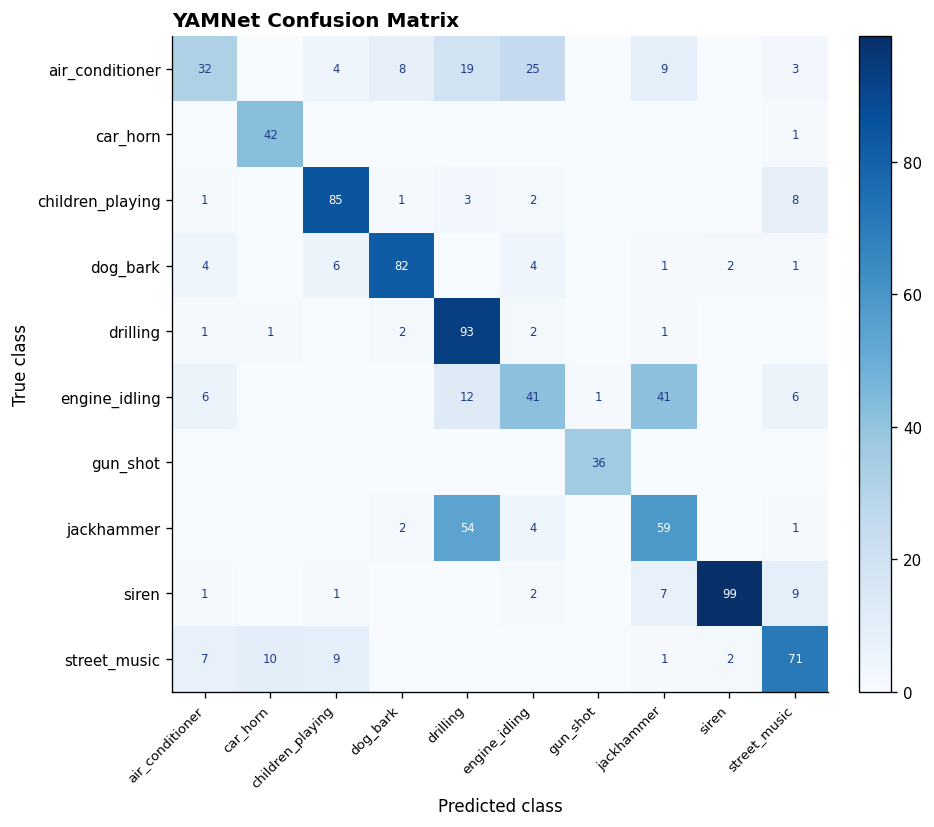

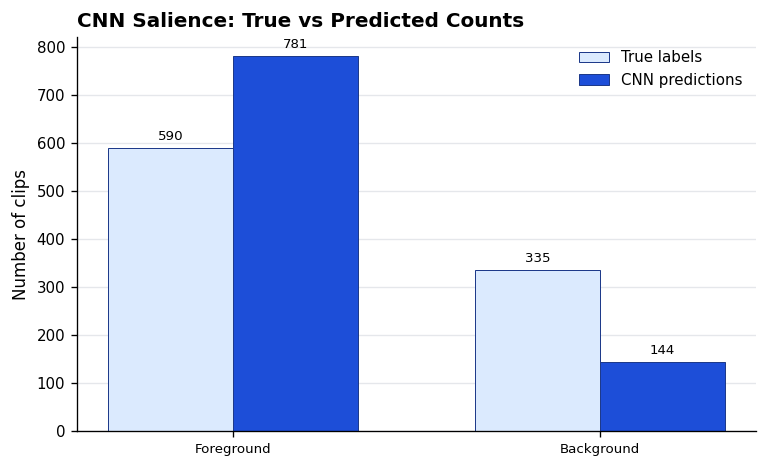

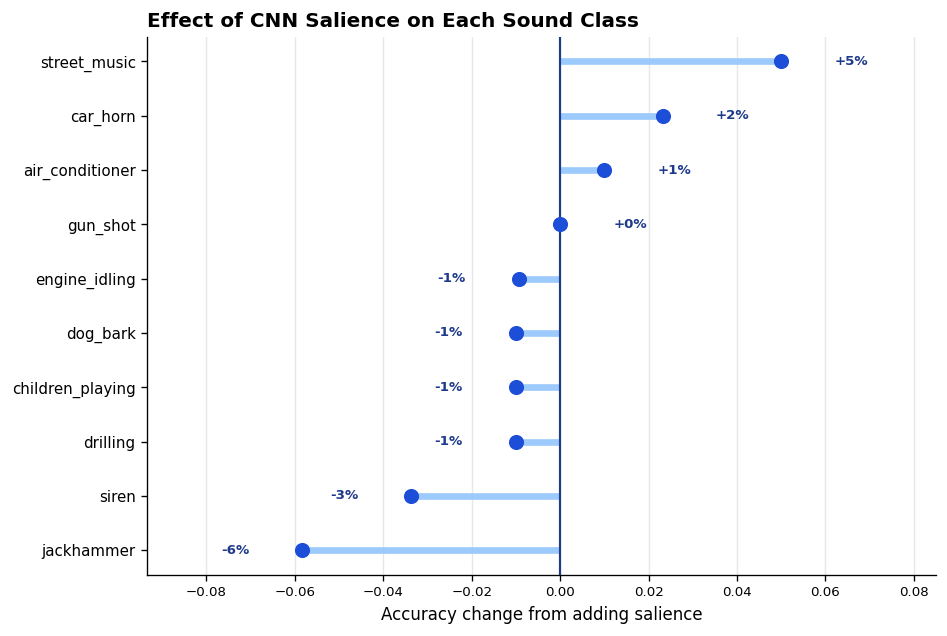

Saved:
fig_yamnet_confusion_heatmap.png
fig_cnn_salience_counts.png
fig_salience_effect_by_class.png


In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Blue theme
blue = "#1D4ED8"
light_blue = "#93C5FD"
pale_blue = "#DBEAFE"
navy = "#1E3A8A"
grid = "#E5E7EB"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False
})

# -------------------------
# 1. YAMNet confusion matrix
# -------------------------
cm = confusion_matrix(y_test_class, yamnet_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(label_encoder.classes_)))
ax.set_yticks(np.arange(len(label_encoder.classes_)))
ax.set_xticklabels(label_encoder.classes_, rotation=45, ha="right")
ax.set_yticklabels(label_encoder.classes_)

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("YAMNet Confusion Matrix", loc="left", fontweight="bold")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        if value > 0:
            ax.text(
                j, i, str(value),
                ha="center",
                va="center",
                fontsize=7,
                color="white" if value > cm.max() * 0.45 else navy
            )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("fig_yamnet_confusion_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


# -------------------------
# 2. CNN salience true vs predicted counts
# -------------------------
true_counts = test_df_salience_results["true_salience_name"].value_counts()
pred_counts = test_df_salience_results["cnn_salience_pred_name"].value_counts()

counts_df = pd.DataFrame({
    "True labels": true_counts,
    "CNN predictions": pred_counts
}).fillna(0)

counts_df = counts_df.loc[["foreground", "background"]]

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(len(counts_df.index))
width = 0.34

bars_true = ax.bar(
    x - width/2,
    counts_df["True labels"],
    width,
    label="True labels",
    color=pale_blue,
    edgecolor=navy,
    linewidth=0.6
)

bars_pred = ax.bar(
    x + width/2,
    counts_df["CNN predictions"],
    width,
    label="CNN predictions",
    color=blue,
    edgecolor=navy,
    linewidth=0.6
)

ax.set_xticks(x)
ax.set_xticklabels(["Foreground", "Background"])
ax.set_ylabel("Number of clips")
ax.set_title("CNN Salience: True vs Predicted Counts", loc="left", fontweight="bold")
ax.grid(axis="y", color=grid)
ax.set_axisbelow(True)
ax.legend(frameon=False)

for bars in [bars_true, bars_pred]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 10,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.savefig("fig_cnn_salience_counts.png", dpi=300, bbox_inches="tight")
plt.show()


# -------------------------
# 3. Combined vs YAMNet: change in accuracy by class
# -------------------------
combined_test_results = test_df.copy()
combined_test_results["true_class"] = test_df["class"].values
combined_test_results["combined_pred_class"] = label_encoder.inverse_transform(combined_preds)
combined_test_results["combined_correct"] = (
    combined_test_results["true_class"] == combined_test_results["combined_pred_class"]
)

comparison_df = pd.DataFrame({
    "YAMNet": yamnet_test_results.groupby("true_class")["yamnet_correct"].mean(),
    "Combined": combined_test_results.groupby("true_class")["combined_correct"].mean()
})

comparison_df["Change"] = comparison_df["Combined"] - comparison_df["YAMNet"]
comparison_df = comparison_df.sort_values("Change")

fig, ax = plt.subplots(figsize=(8, 5.4))

y = np.arange(len(comparison_df))
changes = comparison_df["Change"].values

# Lines from zero to change
ax.hlines(
    y=y,
    xmin=0,
    xmax=changes,
    color=light_blue,
    linewidth=4,
    alpha=0.9
)

# Points
ax.scatter(
    changes,
    y,
    color=blue,
    s=65,
    zorder=3
)

# Zero line
ax.axvline(0, color=navy, linewidth=1.3)

ax.set_yticks(y)
ax.set_yticklabels(comparison_df.index)
ax.set_xlabel("Accuracy change from adding salience")
ax.set_title("Effect of CNN Salience on Each Sound Class", loc="left", fontweight="bold")
ax.grid(axis="x", color=grid)
ax.set_axisbelow(True)

# Add wider x-limits so labels do not overlap or go outside
min_x = min(changes.min() - 0.035, -0.08)
max_x = max(changes.max() + 0.035, 0.08)
ax.set_xlim(min_x, max_x)

for i, v in enumerate(changes):
    label = f"{v*100:+.0f}%"
    
    if v >= 0:
        x_text = v + 0.012
        ha = "left"
    else:
        x_text = v - 0.012
        ha = "right"
    
    ax.text(
        x_text,
        i,
        label,
        va="center",
        ha=ha,
        fontsize=8,
        color=navy,
        fontweight="bold"
    )

plt.tight_layout()
plt.savefig("fig_salience_effect_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print("fig_yamnet_confusion_heatmap.png")
print("fig_cnn_salience_counts.png")
print("fig_salience_effect_by_class.png")

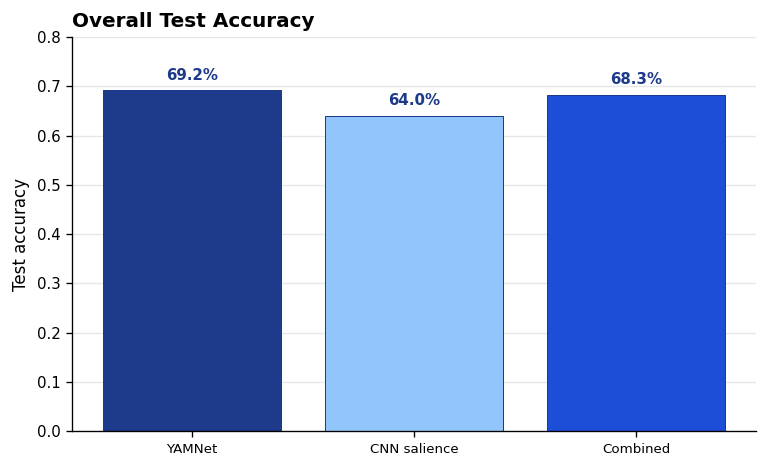

In [35]:
# -------------------------
# Overall accuracy bar plot
# -------------------------
summary_df = pd.DataFrame({
    "System": ["YAMNet", "CNN salience", "Combined"],
    "Accuracy": [yamnet_acc, salience_acc, combined_acc]
})

fig, ax = plt.subplots(figsize=(6.5, 4))

bars = ax.bar(
    summary_df["System"],
    summary_df["Accuracy"],
    color=[navy, light_blue, blue],
    edgecolor=navy,
    linewidth=0.6
)

ax.set_ylim(0, 0.8)
ax.set_ylabel("Test accuracy")
ax.set_title("Overall Test Accuracy", loc="left", fontweight="bold")
ax.grid(axis="y", color=grid)
ax.set_axisbelow(True)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.015,
        f"{h*100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color=navy
    )

plt.tight_layout()
plt.savefig("fig_overall_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

,threshold,accuracy,macro_f1,foreground_recall,background_recall,predicted_foreground,predicted_background
0,0.1,0.640000,0.530957,0.879661,0.217910,781,144
1,0.2,0.636757,0.499033,0.910169,0.155224,820,105
2,0.3,0.645405,0.493130,0.935593,0.134328,842,83
3,0.4,0.646486,0.481300,0.949153,0.113433,857,68
4,0.5,0.644324,0.468522,0.955932,0.095522,867,58


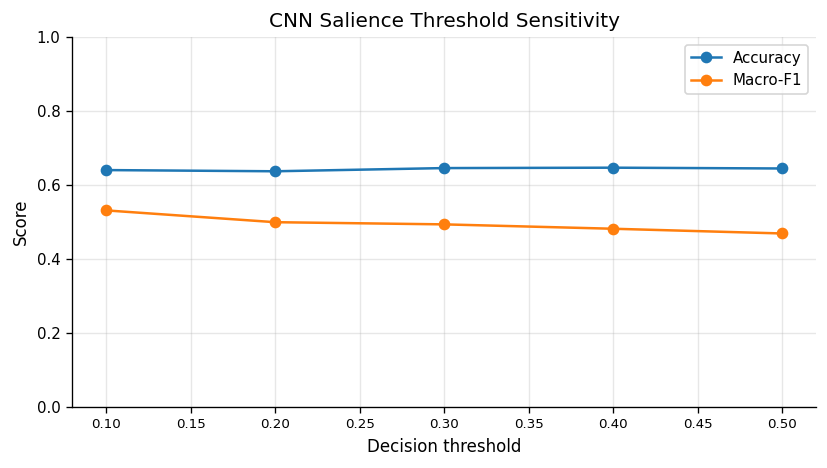

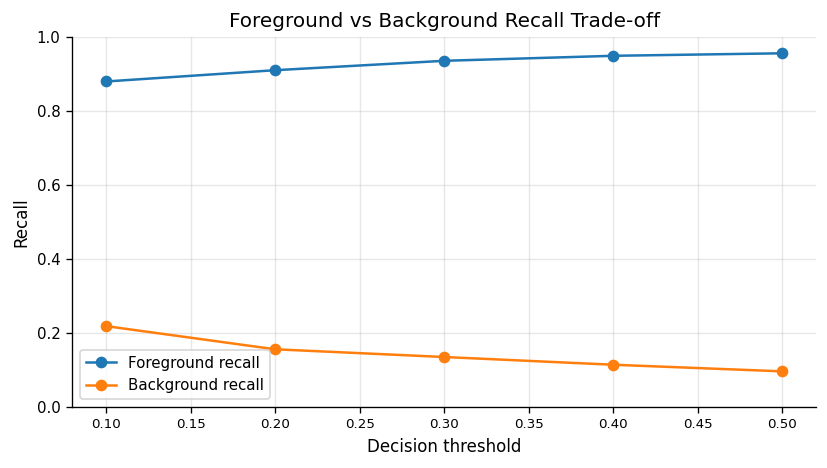

In [36]:
# =========================
# EXTRA ANALYSIS: SALIENCE THRESHOLD SENSITIVITY
# This tests how the CNN behaves at different thresholds.
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for threshold in thresholds_to_test:
    preds_at_t = (test_probs_sal >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_sal, preds_at_t),
        "macro_f1": f1_score(y_test_sal, preds_at_t, average="macro"),
        "foreground_recall": recall_score(y_test_sal, preds_at_t, pos_label=0),
        "background_recall": recall_score(y_test_sal, preds_at_t, pos_label=1),
        "predicted_foreground": np.sum(preds_at_t == 0),
        "predicted_background": np.sum(preds_at_t == 1)
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

threshold_results_df.to_csv("threshold_sensitivity_results.csv", index=False)

# Plot accuracy and macro-F1
plt.figure(figsize=(7, 4))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["macro_f1"],
    marker="o",
    label="Macro-F1"
)

plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("CNN Salience Threshold Sensitivity")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("fig_threshold_sensitivity_scores.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot foreground/background recall trade-off
plt.figure(figsize=(7, 4))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["foreground_recall"],
    marker="o",
    label="Foreground recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["background_recall"],
    marker="o",
    label="Background recall"
)

plt.xlabel("Decision threshold")
plt.ylabel("Recall")
plt.title("Foreground vs Background Recall Trade-off")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("fig_threshold_recall_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()